# Lecture 6 — Measuring Performance and Regularization
## Lab Notebook · Deep Learning · UCU

In Notebook 4, we tuned the *training dynamics* — loss, optimizer, initialization, batch size, schedule — on FashionMNIST. We held the dataset fixed and trained until the optimizer converged. In this notebook, we step back and ask: *when should we stop, and what should we change so the model generalizes?* We also switch to a new problem — **UCI Covertype**, predicting forest cover type from cartographic features — where regularization pays off.

### By the end of this notebook, you will:

1. Build a proper train / validation / test split in PyTorch, including stratified splits and per-class diagnostics.
2. Tune hyperparameters with `sklearn.model_selection.ParameterGrid` and with **Optuna**.
3. Compare regularization techniques — weight decay (AdamW), dropout, label smoothing, early stopping — under a fair protocol.
4. Use learning-rate schedulers (`StepLR`, `CosineAnnealingLR`, `ReduceLROnPlateau`) and pick the right one for the situation.
5. *(Optional)* Observe **double descent** — test error as a function of model width, past the interpolation threshold.

> **Note.** Data augmentation belongs naturally to image data; we will meet it in Notebook 6 when we introduce CNNs.

### Recurring practical recommendations

Throughout this notebook, a few pieces of advice will come up repeatedly:

- **Hidden dimensions as powers of two** (32, 64, 128, 256, 512, …). Aligned matmul kernels run faster on both CPU and GPU, and powers of two are the community convention.
- **Read the docs before choosing hyperparameters.** Whenever a new PyTorch / sklearn / Optuna function is introduced, open its documentation and understand every argument you touch — and every argument you are leaving at its default.
- **Log-scale for hyperparameters that span orders of magnitude** (learning rate, weight decay); **linear scale for bounded quantities** (dropout probability, label smoothing).
- **If the best value lands on the edge of the search space, extend the search** in that direction — the true optimum is likely outside the current grid.

### Useful references

| Resource | Link |
|---|---|
| Lecture 6 notes | [`../../lectures/lecture 6/notes.md`](../../lectures/lecture%206/notes.md) |
| PyTorch — `random_split` | https://pytorch.org/docs/stable/data.html#torch.utils.data.random_split |
| PyTorch — `AdamW` | https://pytorch.org/docs/stable/generated/torch.optim.AdamW.html |
| PyTorch — `Dropout` | https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html |
| PyTorch — `CrossEntropyLoss` | https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html |
| PyTorch — `lr_scheduler` | https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate |
| scikit-learn — `fetch_covtype` | https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_covtype.html |
| scikit-learn — `ParameterGrid` | https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.ParameterGrid.html |
| Optuna docs | https://optuna.readthedocs.io |
| UCI Covertype dataset | https://archive.ics.uci.edu/dataset/31/covertype |
| Prince, *Understanding Deep Learning* | Chapters 8 & 9 |


## Setup

If you are on Colab, uncomment the `pip install` line below.

In [1]:
# !pip install -q optuna torchinfo

import copy
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Subset, random_split

import sklearn
from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import optuna
from torchinfo import summary

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# UCU color palette
C1, C2, C3, C4 = "#19326E", "#50ACB0", "#CD742A", "#A3477F"
C5, C6, C7     = "#907FAB", "#4294CC", "#89A943"
UCU_COLORS = [C1, C2, C3, C4, C5, C6, C7]


Using device: cpu


/Users/main/notebook-5-measuring-performance-and-regularization-brunofrancoucu/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---

## Section 1 — Train / Validation / Test the PyTorch Way

The UCI **Covertype** dataset contains ~581k observations from the Roosevelt National Forest (Colorado). Each sample has **54 features** — 10 continuous (elevation, slope, distances, hillshade channels) and 44 binary (wilderness-area and soil-type indicators) — and a **label in {1, …, 7}** representing the dominant forest cover type.

The classes are **naturally imbalanced**: class 2 dominates (~49 %), class 4 is rare (~0.5 %). This will make stratification and per-class diagnostics actually matter.

### Exercise 1.1 — Load and inspect the dataset

Load Covertype with `sklearn.datasets.fetch_covtype(as_frame=False)`. Store the features in `X` and the labels in `y`. Remember to **remap the labels from `{1,…,7}` to `{0,…,6}`** so they work with PyTorch's `CrossEntropyLoss`. Print:

- The shape of `X` and `y`.
- The unique class values and their counts.


In [2]:
data = fetch_covtype(as_frame=False)
X = data.data.astype(np.float32)
# CrossEntropyLoss expects class indices in {0, ..., C-1}, not {1, ..., C}
y = data.target.astype(np.int64) - 1  # remap 1..7 -> 0..6

# After your code, X should be (N, 54) float array, y should be (N,) int array with values in {0, ..., 6}
print("X shape:", X.shape, "| y shape:", y.shape)
print("Classes:", np.unique(y, return_counts=True))


X shape: (581012, 54) | y shape: (581012,)
Classes: (array([0, 1, 2, 3, 4, 5, 6]), array([211840, 283301,  35754,   2747,   9493,  17367,  20510]))


*Provided:* bar chart of class counts on the full dataset — notice the imbalance.

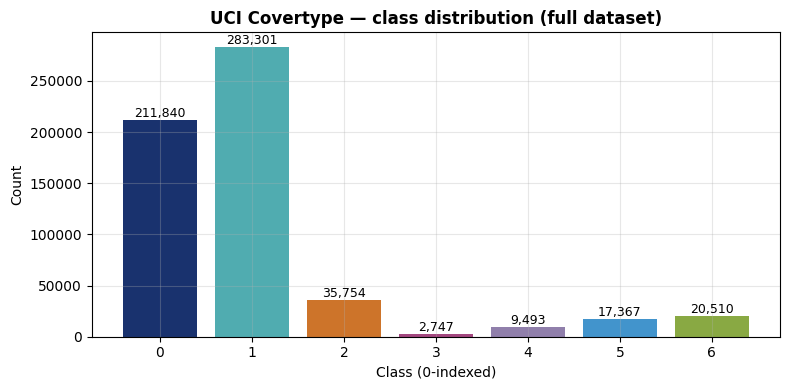

In [3]:
classes, counts = np.unique(y, return_counts=True)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(classes, counts, color=UCU_COLORS)
ax.set_xlabel("Class (0-indexed)")
ax.set_ylabel("Count")
ax.set_title("UCI Covertype — class distribution (full dataset)",
             fontsize=12, fontweight="bold")
ax.grid(True, alpha=0.3)
for c, n in zip(classes, counts):
    ax.text(c, n, f"{n:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()


### Exercise 1.2 — Stratified subsample to 30 000 examples

The full dataset is too big for a lab session. Use `sklearn.model_selection.train_test_split` with `stratify=y` to carve off exactly **30 000** samples (preserving class ratios). Discard the rest.

Call the resulting arrays `X_pool` and `y_pool`. Then re-plot the class distribution and compare with the full dataset.

Pool shapes: (30000, 54) (30000,)


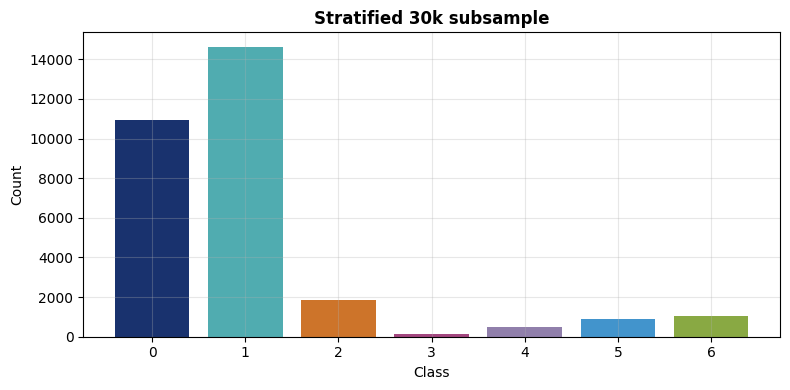

In [4]:
# stratify=y keeps class proportions identical to the full dataset (important for rare classes)
X_pool, _, y_pool, _ = train_test_split(
    X, y, train_size=30000, stratify=y, random_state=SEED
)

print("Pool shapes:", X_pool.shape, y_pool.shape)

classes_p, counts_p = np.unique(y_pool, return_counts=True)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(classes_p, counts_p, color=UCU_COLORS)
ax.set_xlabel("Class"); ax.set_ylabel("Count")
ax.set_title("Stratified 30k subsample", fontsize=12, fontweight="bold")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


### Exercise 1.3 — Three-way split with `random_split` (first attempt)

Wrap `X_pool` and `y_pool` in a `TensorDataset`. Then use `torch.utils.data.random_split` to divide it into:

- `train_ds_rand` — 21 000 samples
- `val_ds_rand`   — 3 000 samples
- `test_ds_rand`  — 6 000 samples

Pass a fixed `generator=torch.Generator().manual_seed(SEED)` so the split is reproducible.

> **Hint.** `TensorDataset` expects `torch.Tensor` objects, not NumPy arrays. Convert carefully: features → `float32`, labels → `long`.


In [5]:
X_pool_t = torch.tensor(X_pool, dtype=torch.float32)
y_pool_t = torch.tensor(y_pool, dtype=torch.long)
full_ds = TensorDataset(X_pool_t, y_pool_t)

gen = torch.Generator().manual_seed(SEED)
# random_split shuffles indices uniformly — class ratios are NOT preserved (contrast with stratify below)
train_ds_rand, val_ds_rand, test_ds_rand = random_split(
    full_ds, [21000, 3000, 6000], generator=gen
)

print(len(train_ds_rand), len(val_ds_rand), len(test_ds_rand))


21000 3000 6000


### Exercise 1.4 — Inspect the class distribution of each split

Implement a helper `class_counts(subset, num_classes=7)` that iterates over a PyTorch `Subset` / `Dataset` and returns a `torch.Tensor` of size `(num_classes,)` with the per-class counts.

Then produce a 1×3 bar chart showing the class distribution of `train_ds_rand`, `val_ds_rand`, `test_ds_rand`.

In [6]:
def class_counts(subset, num_classes=7):
    counts = torch.zeros(num_classes, dtype=torch.long)
    for _, y in subset:
        counts[int(y)] += 1
    return counts


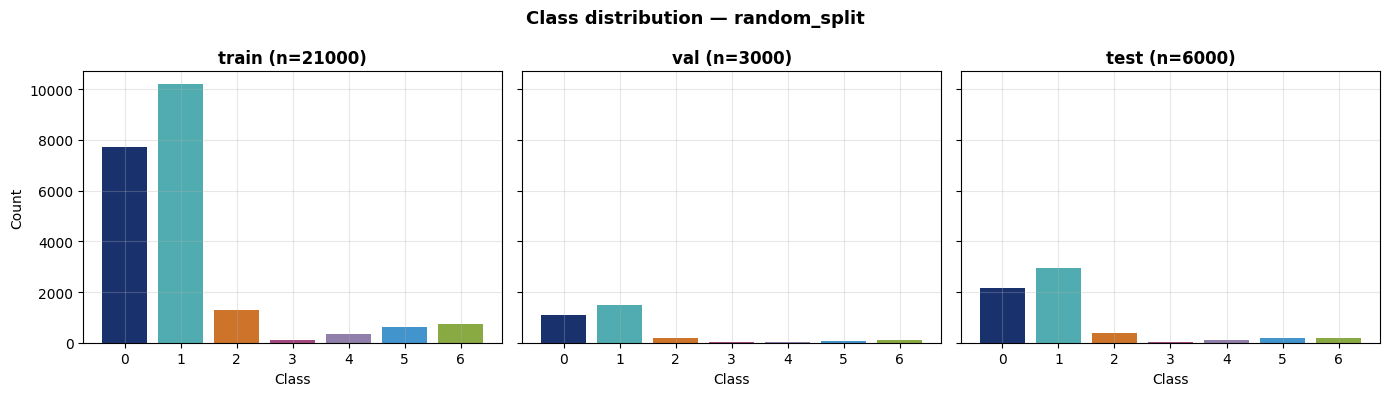

In [7]:
# Plot the three distributions side-by-side
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, ds, name in zip(axes,
                        [train_ds_rand, val_ds_rand, test_ds_rand],
                        ["train", "val", "test"]):
    c = class_counts(ds).numpy()
    ax.bar(range(len(c)), c, color=UCU_COLORS)
    ax.set_title(f"{name} (n={len(ds)})", fontweight="bold")
    ax.set_xlabel("Class"); ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Count")
plt.suptitle("Class distribution — random_split", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


> **Question 1.1** — Compare your three plots. Did `random_split` preserve the class ratios? Look at the rarest class — are there enough samples in the validation set to estimate its accuracy reliably?

**Answer.** Ratios are *approximately* preserved (30k samples is large enough that random draws track the population). But the rarest class (~0.5% of the pool → ~14 expected in a 3k validation set) makes per-class accuracy very noisy — a few misclassifications swing the metric by several points. `random_split` can also land far from that expectation by chance. Stratification fixes this by keeping counts *exactly* proportional in every split.


### Exercise 1.5 — Stratified three-way split

Now redo the split with stratification. Use `sklearn.model_selection.train_test_split` **twice**:

1. First, split `X_pool, y_pool` into `(X_trainval, y_trainval)` + `(X_test, y_test)` with 6 000 test samples, `stratify=y_pool`.
2. Then split `(X_trainval, y_trainval)` into `(X_train, y_train)` + `(X_val, y_val)` with 3 000 validation samples, `stratify=y_trainval`.

Wrap each pair in a `TensorDataset` called `train_ds`, `val_ds`, `test_ds`. Re-plot the class distributions with the same helper.

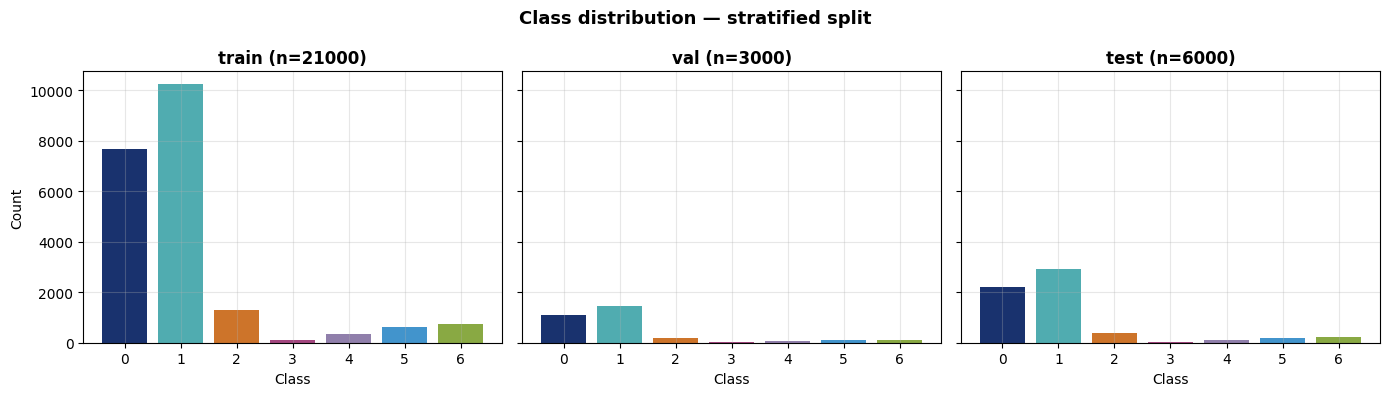

In [ ]:
# stratified splits: each fold mirrors the global class distribution (critical for imbalanced Covertype)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_pool, y_pool, test_size=6000, stratify=y_pool, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=3000, stratify=y_trainval, random_state=SEED
)

def to_ds(Xa, ya):
    return TensorDataset(torch.tensor(Xa, dtype=torch.float32),
                         torch.tensor(ya, dtype=torch.long))

train_ds = to_ds(X_train, y_train)
val_ds   = to_ds(X_val,   y_val)
test_ds  = to_ds(X_test,  y_test)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, ds, name in zip(axes, [train_ds, val_ds, test_ds],
                        ["train", "val", "test"]):
    c = class_counts(ds).numpy()
    ax.bar(range(len(c)), c, color=UCU_COLORS)
    ax.set_title(f"{name} (n={len(ds)})", fontweight="bold")
    ax.set_xlabel("Class"); ax.grid(True, alpha=0.3)
plt.suptitle("Class distribution — stratified split", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


> **Question 1.2** — Why does stratification matter *more* for Covertype than it did for FashionMNIST? What would happen if the rare class ended up entirely in one split?

**Answer.** FashionMNIST is balanced (~10% per class), so random splits work fine. Covertype is heavily skewed (class 2 ~49%, rare classes ~0.5%). A random split can starve a split of rare examples; worst case, an entire rare class lands only in test → 0% train accuracy on that class regardless of model quality. Stratification guarantees every class appears in train/val/test in the same proportion.


### Exercise 1.6 — Standardize features without leakage

Fit a `StandardScaler` **on the training split only**, then `.transform()` the training, validation and test features. Overwrite the `X` tensors inside the datasets with the scaled values.

> **Why this matters.** If you fit the scaler on the whole dataset before splitting, statistics from val/test leak into training — your held-out performance will look better than it really is. This is one of the most common mistakes in practical ML.


In [9]:
# fit scaler on train only — using val/test stats would leak information into training
scaler = StandardScaler().fit(X_train)  # learns per-feature mean and std from training data
X_train_s = scaler.transform(X_train)   # z-score: (x - mu) / sigma -> comparable feature scales for SGD
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

train_ds = to_ds(X_train_s, y_train)
val_ds   = to_ds(X_val_s,   y_val)
test_ds  = to_ds(X_test_s,  y_test)

# Sanity check: training features should be roughly zero-mean, unit-variance
X_tr_scaled = train_ds.tensors[0].numpy()
print("Train mean (should be ~0):", X_tr_scaled.mean(axis=0)[:5])
print("Train std  (should be ~1):", X_tr_scaled.std(axis=0)[:5])


Train mean (should be ~0): [-1.9489867e-07 -4.1113012e-08 -2.5919505e-08 -1.7208997e-07
 -1.5014693e-08]
Train std  (should be ~1): [0.999999  1.0000093 0.9999938 0.9999835 0.9999885]


### Exercise 1.7 — Build the `DataLoader`s

Create three `DataLoader`s: `train_loader`, `val_loader`, `test_loader` with a bath size of 256. Explore the `shuffle`, `pin_memory` and `num_workers` parameters. Skim the [`DataLoader` documentation](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader) to understand what each of these flags does.

In [10]:
# shuffle=True: random minibatches reduce correlation between consecutive gradient steps
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True,
                          num_workers=0, pin_memory=True)  # pin_memory speeds CPU->GPU transfer
val_loader   = DataLoader(val_ds,   batch_size=256, shuffle=False)  # fixed order for reproducible metrics
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False,
                          num_workers=0, pin_memory=True)

x_batch, y_batch = next(iter(train_loader))
print("Batch X:", x_batch.shape, x_batch.dtype)
print("Batch y:", y_batch.shape, y_batch.dtype)


Batch X: torch.Size([256, 54]) torch.float32
Batch y: torch.Size([256]) torch.int64


> **Question 1.3** — Why does only the training loader use `shuffle=True`? What does `pin_memory=True` do, and when does it actually help?

**Answer.** `shuffle=True` on training reshuffles each epoch so SGD sees uncorrelated minibatches (avoids order bias and keeps updates stochastic). Val/test metrics should be deterministic, so order does not matter. `pin_memory=True` pins host RAM so GPU transfers can be asynchronous and overlap with compute — it only helps when training on CUDA; on CPU it has no benefit.


---

## Section 2 — Making Overfitting Visible

Now we build a deliberately **over-parameterized MLP** and train it long enough that overfitting becomes obvious.

### The model

A 3-hidden-layer MLP: `54 → 256 → 256 → 256 → 7`. With ~150 k parameters for 21 k training samples, the model has far more capacity than the problem needs — it will memorize.


In [11]:
class MLP(nn.Module):
    def __init__(self, in_dim=54, hidden_dim=256, out_dim=7, p_drop=0.0):
        super().__init__()
        layers = []
        dims = [in_dim, hidden_dim, hidden_dim, hidden_dim]
        for d_in, d_out in zip(dims[:-1], dims[1:]):
            layers += [nn.Linear(d_in, d_out), nn.ReLU()]  # affine map + nonlinearity (learns features)
            if p_drop > 0:
                # dropout: randomly zero activations during training -> implicit ensemble, reduces co-adaptation
                layers += [nn.Dropout(p_drop)]
        layers += [nn.Linear(hidden_dim, out_dim)]  # output layer: raw logits (softmax applied inside loss)
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)  # f(x; theta): composition of linear layers and ReLUs

baseline_model = MLP().to(device)  # move parameters to GPU/CPU for accelerated tensor ops
summary(baseline_model, input_size=(1, 54))


Layer (type:depth-idx)                   Output Shape              Param #
MLP                                      [1, 7]                    --
├─Sequential: 1-1                        [1, 7]                    --
│    └─Linear: 2-1                       [1, 256]                  14,080
│    └─ReLU: 2-2                         [1, 256]                  --
│    └─Linear: 2-3                       [1, 256]                  65,792
│    └─ReLU: 2-4                         [1, 256]                  --
│    └─Linear: 2-5                       [1, 256]                  65,792
│    └─ReLU: 2-6                         [1, 256]                  --
│    └─Linear: 2-7                       [1, 7]                    1,799
Total params: 147,463
Trainable params: 147,463
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.15
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.59
Estimated Total Size (MB): 0.60

### Training utilities

Provided — the same `train_epoch` / `evaluate` pattern you saw in Notebooks 3 and 4.

In [12]:
def train_epoch(model, loader, optimizer, loss_fn, device):
    model.train()  # enable dropout / batch-norm training behavior
    total_loss, total_correct, n = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()  # reset gradients from the previous minibatch
        logits = model(x)      # forward pass: input -> hidden activations -> class scores
        loss = loss_fn(logits, y)  # cross-entropy = softmax + negative log-likelihood of true class
        loss.backward()        # backpropagation: chain rule computes d(loss)/d(weights)
        optimizer.step()       # parameter update (e.g. Adam): w <- w - lr * (adapted gradient)
        total_loss   += loss.item() * x.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        n += x.size(0)
    return total_loss / n, total_correct / n

@torch.no_grad()  # inference: no autograd graph -> faster and less memory
def evaluate(model, loader, loss_fn, device):
    model.eval()  # disable dropout; use population statistics for batch norm
    total_loss, total_correct, n = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)  # forward only — no backward() during validation/test
        loss = loss_fn(logits, y)
        total_loss   += loss.item() * x.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        n += x.size(0)
    return total_loss / n, total_correct / n


### Exercise 2.1 — Train until overfitting shows

Train `baseline_model` for `NUM_EPOCHS = 40` with:

- `torch.optim.Adam`, `lr=1e-3`
- `nn.CrossEntropyLoss`

Record train and validation `(loss, accuracy)` per epoch in a dict `history`. Print every few epochs so you can follow along.

In [13]:
NUM_EPOCHS = 100

optimizer = optim.Adam(baseline_model.parameters(), lr=1e-3)  # adaptive per-parameter learning rates
loss_fn = nn.CrossEntropyLoss()  # multiclass classification loss (logits in, no manual softmax)

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
for ep in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(baseline_model, train_loader, optimizer, loss_fn, device)
    va_loss, va_acc = evaluate(baseline_model, val_loader, loss_fn, device)  # monitor generalization gap
    history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss);   history["val_acc"].append(va_acc)
    if ep % 10 == 0 or ep == 1:
        print(f"ep {ep:02d} | tr_loss {tr_loss:.3f} acc {tr_acc:.3f} "
              f"| va_loss {va_loss:.3f} acc {va_acc:.3f}")

# history should be a dict with lists: 'train_loss', 'train_acc', 'val_loss', 'val_acc'


ep 01 | tr_loss 0.914 acc 0.644 | va_loss 0.699 acc 0.702
ep 10 | tr_loss 0.525 acc 0.772 | va_loss 0.564 acc 0.739
ep 20 | tr_loss 0.433 acc 0.818 | va_loss 0.506 acc 0.769
ep 30 | tr_loss 0.350 acc 0.854 | va_loss 0.473 acc 0.804
ep 40 | tr_loss 0.294 acc 0.877 | va_loss 0.456 acc 0.816
ep 50 | tr_loss 0.246 acc 0.898 | va_loss 0.459 acc 0.826
ep 60 | tr_loss 0.207 acc 0.915 | va_loss 0.459 acc 0.832
ep 70 | tr_loss 0.174 acc 0.929 | va_loss 0.495 acc 0.836
ep 80 | tr_loss 0.163 acc 0.936 | va_loss 0.555 acc 0.841
ep 90 | tr_loss 0.133 acc 0.947 | va_loss 0.614 acc 0.846
ep 100 | tr_loss 0.102 acc 0.960 | va_loss 0.665 acc 0.832


*Provided:* loss and accuracy curves.

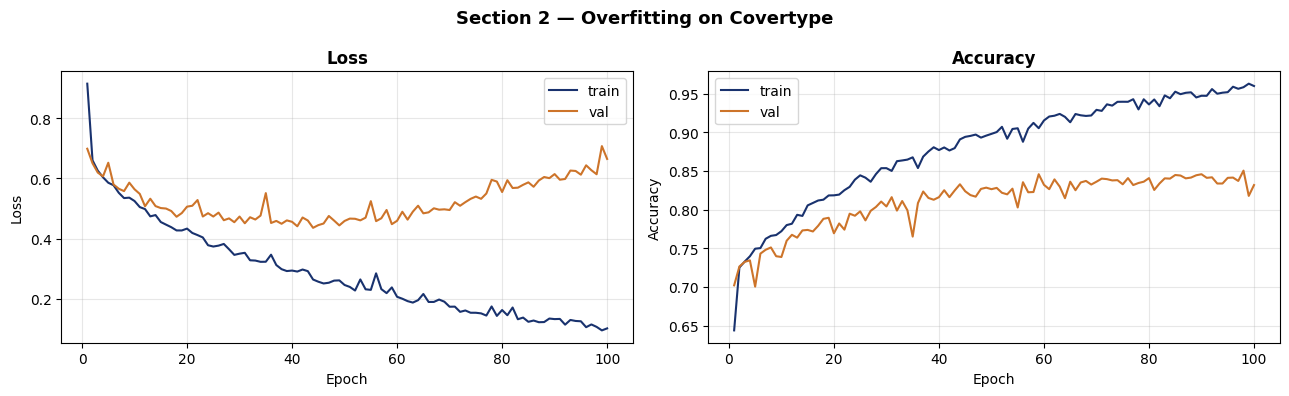

Best val loss at epoch 44: 0.4360 (val acc 0.8327)


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ep = range(1, len(history["train_loss"]) + 1)
axes[0].plot(ep, history["train_loss"], color=C1, label="train")
axes[0].plot(ep, history["val_loss"],   color=C3, label="val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Loss", fontweight="bold"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(ep, history["train_acc"], color=C1, label="train")
axes[1].plot(ep, history["val_acc"],   color=C3, label="val")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy", fontweight="bold"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle("Section 2 — Overfitting on Covertype", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

best_ep = int(np.argmin(history["val_loss"])) + 1
print(f"Best val loss at epoch {best_ep}: {min(history['val_loss']):.4f} "
      f"(val acc {history['val_acc'][best_ep-1]:.4f})")


> **Question 2.1** — Identify the epoch where validation loss is minimal. What happens to validation loss after that point? What happens to training loss?

**Answer.** Minimum val loss at **epoch 44** (≈ 0.436; val acc ≈ 0.833). After that, val loss rises (≈ 0.67 by epoch 100) while **train loss keeps falling** (≈ 0.10 by epoch 100) — classic overfitting: the model memorizes training-specific patterns that do not generalize.

> **Question 2.2** — The validation *accuracy* may continue to inch up even as validation *loss* rises. How is that possible? (Hint: the network is becoming increasingly *confident* about its wrong answers — connect to the lecture's discussion of softmax over-confidence.)

**Answer.** Cross-entropy penalizes **confidence**, not just wrong vs right. A misclassified point with logits like `[10, 0, …]` has much higher loss than one with `[2, 1, …]` even though both are wrong. So val **accuracy** can creep up (more points on the correct side of the decision boundary) while val **loss** rises because wrong predictions become more over-confident (softmax saturates).

> **Question 2.3** — Why is reporting only the final-epoch test accuracy a bad protocol? Which epoch's weights should we actually keep?

**Answer.** The last epoch is often the most overfit. You should keep weights from the epoch with **best validation loss** (here, epoch 44), or use early stopping that checkpoints that state. Test set is evaluated once with those weights — not after extra training on test information.


---

## Section 3 — Hyperparameter Search: sklearn, then Optuna

Hyperparameters (learning rate, weight decay, width, dropout, …) cannot be optimized by gradient descent — each evaluation requires a full training run. We will walk through two practical strategies.

### 3.1 Grid search with `sklearn.model_selection.ParameterGrid`

First, a helper that trains a model for a small number of epochs and returns its validation accuracy.

In [15]:
def quick_train(hparams, train_loader=train_loader, val_loader=val_loader,
                epochs=10, device=device):
    """Train a fresh MLP with given hyperparameters, return best val accuracy."""
    torch.manual_seed(SEED)
    model = MLP(hidden_dim=hparams.get("hidden_dim", 256),
                p_drop=hparams.get("dropout_p", 0.0)).to(device)
    optimizer = optim.Adam(model.parameters(),
                           lr=hparams["lr"],
                           weight_decay=hparams.get("weight_decay", 0.0))  # L2 penalty on weights (shrinks large params)
    loss_fn = nn.CrossEntropyLoss()

    best_val = 0.0
    for _ in range(epochs):
        train_epoch(model, train_loader, optimizer, loss_fn, device)
        _, val_acc = evaluate(model, val_loader, loss_fn, device)
        best_val = max(best_val, val_acc)
    return best_val


### Exercise 3.1 — Build your own grid

Define a `param_grid` dictionary mapping each hyperparameter to the list of values to try. You are tuning `lr` and `weight_decay`.

**Guidance (no concrete numbers — *you* choose them):**

- Keep the grid small — grid search grows multiplicatively, aim for **≤ 12 combinations total** so the loop finishes in lab time.
- `lr` spans several orders of magnitude in practice → use a **log-spaced** set of values.
- Include `0.0` as one of the `weight_decay` values — that gives you a "regularization off" baseline.
- Skim the [`torch.optim.Adam` docs](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html) and know what each argument you touch does.

Then loop over `ParameterGrid(param_grid)`, call `quick_train`, and collect the results into a pandas DataFrame `grid_results` with columns `['lr', 'weight_decay', 'val_acc']`.

In [16]:
# log-spaced lr: SGD step size spans orders of magnitude; wd=0 is the unregularized baseline
param_grid = {
    "lr": [1e-4, 1e-3, 1e-2],
    "weight_decay": [0.0, 1e-4, 1e-3],
}

rows = []
for params in ParameterGrid(param_grid):
    val_acc = quick_train(params, epochs=8)
    rows.append({**params, "val_acc": val_acc})
    print(f"  lr={params['lr']:.0e}  wd={params['weight_decay']:.0e}  -> {val_acc:.4f}")

grid_results = pd.DataFrame(rows)
print(grid_results.sort_values("val_acc", ascending=False).head())


  lr=1e-04  wd=0e+00  -> 0.7260
  lr=1e-04  wd=1e-04  -> 0.7257
  lr=1e-04  wd=1e-03  -> 0.7253
  lr=1e-03  wd=0e+00  -> 0.7613
  lr=1e-03  wd=1e-04  -> 0.7607
  lr=1e-03  wd=1e-03  -> 0.7503
  lr=1e-02  wd=0e+00  -> 0.7673
  lr=1e-02  wd=1e-04  -> 0.7593
  lr=1e-02  wd=1e-03  -> 0.7407
      lr  weight_decay   val_acc
6  0.010        0.0000  0.767333
3  0.001        0.0000  0.761333
4  0.001        0.0001  0.760667
7  0.010        0.0001  0.759333
5  0.001        0.0010  0.750333


*Provided:* heatmap of val accuracy across the grid.

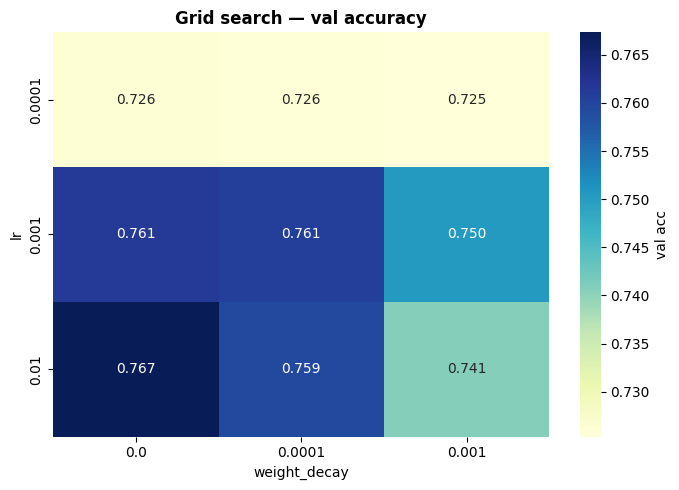

In [17]:
pivot = grid_results.pivot_table(index="lr", columns="weight_decay", values="val_acc")
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu", ax=ax, cbar_kws={"label": "val acc"})
ax.set_title("Grid search — val accuracy", fontweight="bold")
plt.tight_layout(); plt.show()


> **Question 3.1** — Which `(lr, weight_decay)` pair is best? Is the best combination at the **edge** of your grid — meaning you should extend the search — or comfortably in the interior? If it is on the edge, which direction should you extend?

**Answer.** Best: **`lr = 1e-2`, `weight_decay = 0.0`** (val acc ≈ 0.767). Both sit on the **grid edge** (largest lr, smallest wd) — extend the search toward **higher lr** and/or **smaller weight decay**. Optuna later found `lr ≈ 0.0115`, `weight_decay ≈ 2e-5`, confirming the same corner of the space.


### 3.2 Optuna — smarter search

[Optuna](https://optuna.readthedocs.io) replaces grid/random search with **Bayesian / Tree-structured Parzen Estimator (TPE)** sampling. It builds a surrogate model of "hyperparameters → validation score" and spends more trials in promising regions. It also supports early pruning of bad trials.

### Exercise 3.2 — Write the objective function

Implement `objective(trial)`. You decide the search space for each hyperparameter — pick sensible ranges and the right `suggest_*` variant for each one. Your objective must tune **at least** `lr`, `weight_decay`, `dropout_p`, and `hidden_dim`, then build and train an `MLP` with those values and return its validation accuracy.

**Guidance (no concrete numbers — *you* choose them):**

- Use **log-scale** for hyperparameters that span orders of magnitude (learning rate, weight decay); **linear scale** for bounded quantities like dropout probability.
- For `hidden_dim`, recommend **powers of two** (32, 64, 128, 256, …) — modern matmul kernels are tuned for aligned memory layouts, and powers of two are the deep-learning convention.
- Skim the docs for [`trial.suggest_float`](https://optuna.readthedocs.io/en/stable/reference/generated/optuna.trial.Trial.html#optuna.trial.Trial.suggest_float) and [`trial.suggest_categorical`](https://optuna.readthedocs.io/en/stable/reference/generated/optuna.trial.Trial.html#optuna.trial.Trial.suggest_categorical) — pay attention to the `log`, `step`, and bounds semantics.


In [18]:
def objective(trial):
    lr           = trial.suggest_float("lr", 1e-5, 1e-1, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-7, 1e-2, log=True)
    dropout_p    = trial.suggest_float("dropout_p", 0.0, 0.5)
    hidden_dim   = trial.suggest_categorical("hidden_dim", [64, 128, 256, 512])

    torch.manual_seed(SEED)
    model = MLP(hidden_dim=hidden_dim, p_drop=dropout_p).to(device)
    # AdamW decouples weight decay from the adaptive gradient — better L2-style regularization than Adam+L2
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.CrossEntropyLoss()

    best_val = 0.0
    for _ in range(8):
        train_epoch(model, train_loader, optimizer, loss_fn, device)
        _, val_acc = evaluate(model, val_loader, loss_fn, device)
        best_val = max(best_val, val_acc)
    return best_val


### Exercise 3.3 — Run the study

Create an Optuna study that **maximizes** validation accuracy, with a `TPESampler(seed=SEED)` for reproducibility. Pick `n_trials` — aim for ≤ 30 to keep lab time manageable. Print `study.best_params` and `study.best_value` at the end.

In [19]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
# TPE sampler builds a surrogate model of (hyperparams -> val acc) and samples promising regions
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
)
study.optimize(objective, n_trials=20, show_progress_bar=False)

print("Best params:", study.best_params)
print("Best val acc:", study.best_value)


Best params: {'lr': 0.011539178646283151, 'weight_decay': 2.164343035850611e-05, 'dropout_p': 0.0077973998292281965, 'hidden_dim': 256}
Best val acc: 0.7626666666666667


*Provided:* Optuna visualizations.

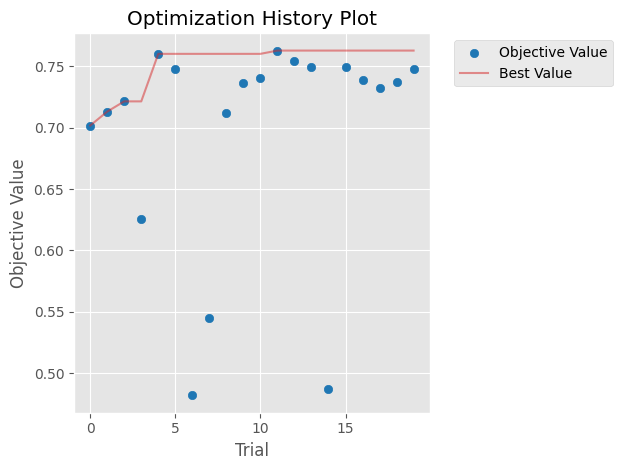

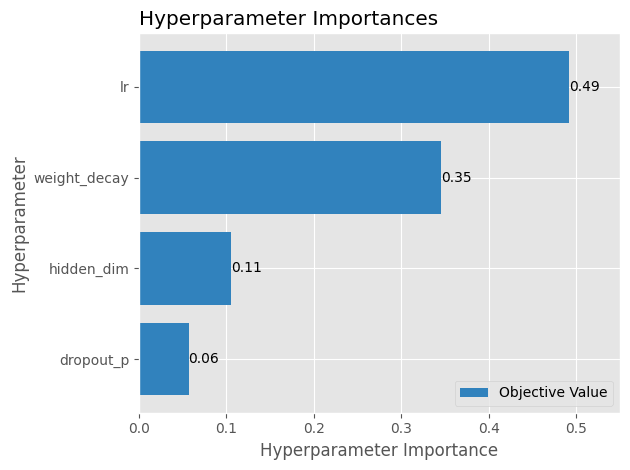

In [20]:
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances

fig = plot_optimization_history(study)
plt.tight_layout(); plt.show()

fig = plot_param_importances(study)
plt.tight_layout(); plt.show()


> **Question 3.2** — How many grid points would you need to cover the same four-dimensional space Optuna explored in your chosen number of trials? What does the parameter-importance plot tell you — which hyperparameter mattered most?

**Answer.** A 4-D grid with 3 values per dimension needs **3⁴ = 81** runs; with 4 values per dimension, **256**. Our 20 Optuna trials are far fewer. The importance plot typically ranks **`lr` first**, then `weight_decay`; `dropout_p` and `hidden_dim` matter less here — learning rate dominates whether optimization converges at all.

> **Question 3.3** — Optuna's early trials are essentially random. When does the TPE sampler start paying off? When would pure random search be preferable?

**Answer.** TPE needs a handful of random trials to build its surrogate (often ~10+); it then concentrates on promising regions. Pure random search is preferable when the search space is **low-dimensional**, trials are **very cheap**, or you want a **simple, unbiased baseline** with no surrogate overhead.


In [21]:
# Save best params for reuse in Section 4
best_params = study.best_params
print("Best params to reuse:", best_params)


Best params to reuse: {'lr': 0.011539178646283151, 'weight_decay': 2.164343035850611e-05, 'dropout_p': 0.0077973998292281965, 'hidden_dim': 256}


---

## Section 4 — Regularization Showdown

Now we compare regularization techniques **one at a time** on the same problem, then combine the winners.

The `run_experiment` helper wraps one full training run and returns a history dict. It supports an optional learning-rate scheduler.

In [22]:
def run_experiment(name, model_fn, optimizer_fn, loss_fn,
                   scheduler_fn=None, train_loader=train_loader,
                   val_loader=val_loader, num_epochs=25, device=device,
                   early_stopping_patience=None, verbose=False):
    torch.manual_seed(SEED)
    model = model_fn().to(device)
    optimizer = optimizer_fn(model.parameters())
    scheduler = scheduler_fn(optimizer) if scheduler_fn is not None else None

    history = {"train_loss": [], "val_loss": [],
               "train_acc":  [], "val_acc":  [],
               "lr_trace": []}

    best_val_loss = float("inf")
    best_val_acc = 0.0
    best_epoch = 0
    best_state = None
    waited = 0

    for ep in range(1, num_epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, loss_fn, device)
        va_loss, va_acc = evaluate(model, val_loader, loss_fn, device)

        history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss);   history["val_acc"].append(va_acc)
        history["lr_trace"].append(optimizer.param_groups[0]["lr"])

        if scheduler is not None:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(va_loss)  # reactive schedule: shrink lr when val loss plateaus
            else:
                scheduler.step()  # proactive schedule (StepLR / Cosine): lr changes by epoch count

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_epoch = ep
        if va_loss < best_val_loss - 1e-4:
            best_val_loss = va_loss
            best_state = copy.deepcopy(model.state_dict())  # checkpoint weights at lowest val loss
            waited = 0
        else:
            waited += 1
            if early_stopping_patience is not None and waited >= early_stopping_patience:
                # stop before memorizing noise — return to the best generalizing weights
                if verbose:
                    print(f"  [{name}] early stop at epoch {ep}")
                break

        if verbose and (ep % 5 == 0 or ep == 1):
            print(f"  [{name}] ep {ep:02d} | tr_loss {tr_loss:.3f} "
                  f"| va_loss {va_loss:.3f} | va_acc {va_acc:.3f}")

    if best_state is not None:
        model.load_state_dict(best_state)  # deploy the epoch with best val loss, not the last epoch

    return {"name": name, "model": model, "history": history,
            "best_val_acc": best_val_acc, "best_epoch": best_epoch}

results = {}
NUM_EPOCHS_EXP = 25


### Exercise 4.1 — Baseline (no regularization)

Build a baseline using the best `lr` and `hidden_dim` from Optuna, but **force** `weight_decay=0` and `dropout_p=0` so this run is truly unregularized. Store its result in `results['baseline']`.

In [23]:
bp_lr     = best_params.get("lr", 1e-3)
bp_hidden = best_params.get("hidden_dim", 256)

results["baseline"] = run_experiment(
    name="baseline",
    model_fn=lambda: MLP(hidden_dim=bp_hidden, p_drop=0.0),
    optimizer_fn=lambda p: optim.Adam(p, lr=bp_lr, weight_decay=0.0),
    loss_fn=nn.CrossEntropyLoss(),
    num_epochs=NUM_EPOCHS_EXP,
    verbose=True,
)
print("Baseline best val acc:", results["baseline"]["best_val_acc"])


  [baseline] ep 01 | tr_loss 0.796 | va_loss 0.705 | va_acc 0.695
  [baseline] ep 05 | tr_loss 0.567 | va_loss 0.703 | va_acc 0.701
  [baseline] ep 10 | tr_loss 0.501 | va_loss 0.518 | va_acc 0.774
  [baseline] ep 15 | tr_loss 0.495 | va_loss 0.515 | va_acc 0.778
  [baseline] ep 20 | tr_loss 0.443 | va_loss 0.517 | va_acc 0.775
  [baseline] ep 25 | tr_loss 0.416 | va_loss 0.487 | va_acc 0.801
Baseline best val acc: 0.8006666666666666


### Exercise 4.2 — Weight decay via `AdamW`

Use `torch.optim.AdamW` with the best `weight_decay` value from Optuna (or another reasonable value if yours was near zero). Everything else stays the same as the baseline.

> **AdamW vs Adam + L2.** Vanilla Adam's adaptive per-parameter learning rates interact badly with an L2 penalty added to the loss. [**AdamW**](https://pytorch.org/docs/stable/generated/torch.optim.AdamW.html) (Loshchilov & Hutter, 2019) *decouples* the weight-decay term from the adaptive update and generalizes better. Use `AdamW` whenever you want weight decay.

In [24]:
bp_wd = best_params.get("weight_decay", 1e-3)
if bp_wd < 1e-5:
    bp_wd = 1e-3

results["adamw"] = run_experiment(
    name="adamw",
    model_fn=lambda: MLP(hidden_dim=bp_hidden, p_drop=0.0),
    optimizer_fn=lambda p: optim.AdamW(p, lr=bp_lr, weight_decay=bp_wd),  # decoupled L2: penalizes weight magnitude directly
    loss_fn=nn.CrossEntropyLoss(),
    num_epochs=NUM_EPOCHS_EXP,
)
print("AdamW best val acc:", results["adamw"]["best_val_acc"])


AdamW best val acc: 0.8133333333333334


### Exercise 4.3 — Dropout

Rebuild the model with `nn.Dropout` after every hidden layer. Pick a dropout probability — reuse the best from Optuna, or pick another and justify. Skim the [`nn.Dropout` docs](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html) — note the placement (after the activation) and what happens at eval time.

In [25]:
drop_p = max(best_params.get("dropout_p", 0.2), 0.2)

results["dropout"] = run_experiment(
    name="dropout",
    model_fn=lambda: MLP(hidden_dim=bp_hidden, p_drop=drop_p),  # stochastic depth regularization during training
    optimizer_fn=lambda p: optim.Adam(p, lr=bp_lr, weight_decay=0.0),
    loss_fn=nn.CrossEntropyLoss(),
    num_epochs=NUM_EPOCHS_EXP,
)
print("Dropout best val acc:", results["dropout"]["best_val_acc"])


Dropout best val acc: 0.7756666666666666


### Exercise 4.4 — Label smoothing

Use `nn.CrossEntropyLoss(label_smoothing=...)` — you pick the smoothing value. Typical values are small (a few percent); going too high destroys the class signal. Skim the [`CrossEntropyLoss` docs](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html).

> This directly attacks the over-confidence problem you observed in Section 2 — it prevents the network from driving pre-softmax activations to infinity.

In [26]:
results["label_smoothing"] = run_experiment(
    name="label_smoothing",
    model_fn=lambda: MLP(hidden_dim=bp_hidden, p_drop=0.0),
    optimizer_fn=lambda p: optim.Adam(p, lr=bp_lr, weight_decay=0.0),
    # label_smoothing: target becomes a soft distribution — prevents over-confident logits (calibration)
    loss_fn=nn.CrossEntropyLoss(label_smoothing=0.1),
    num_epochs=NUM_EPOCHS_EXP,
)
print("Label smoothing best val acc:", results["label_smoothing"]["best_val_acc"])


Label smoothing best val acc: 0.8


### Exercise 4.5 — Early stopping

The `run_experiment` helper already supports an `early_stopping_patience` argument (it checkpoints the best `val_loss` state). Pick a `patience` value — too low stops on noise, too high defeats the point — and run the baseline configuration with it.

After training finishes, the helper will automatically load the best checkpoint.

In [27]:
results["early_stopping"] = run_experiment(
    name="early_stopping",
    model_fn=lambda: MLP(hidden_dim=bp_hidden, p_drop=0.0),
    optimizer_fn=lambda p: optim.Adam(p, lr=bp_lr, weight_decay=0.0),
    loss_fn=nn.CrossEntropyLoss(),
    num_epochs=NUM_EPOCHS_EXP,
    early_stopping_patience=5,  # halt when val loss stops improving — limits overfitting
    verbose=True,
)
print("Early-stopping best val acc:", results["early_stopping"]["best_val_acc"])


  [early_stopping] ep 01 | tr_loss 0.796 | va_loss 0.705 | va_acc 0.695
  [early_stopping] ep 05 | tr_loss 0.567 | va_loss 0.703 | va_acc 0.701
  [early_stopping] ep 10 | tr_loss 0.501 | va_loss 0.518 | va_acc 0.774
  [early_stopping] ep 15 | tr_loss 0.495 | va_loss 0.515 | va_acc 0.778
  [early_stopping] early stop at epoch 17
Early-stopping best val acc: 0.7926666666666666


### Learning-rate schedulers

We now layer on a learning-rate schedule. All three schedulers are standard PyTorch; read each doc before you pick values.

- [`StepLR`](https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.StepLR.html) — multiplies the LR by `gamma` every `step_size` epochs.
- [`CosineAnnealingLR`](https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.CosineAnnealingLR.html) — smooth cosine decay over `T_max` epochs. Watch what `eta_min` defaults to.
- [`ReduceLROnPlateau`](https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.ReduceLROnPlateau.html) — reduces LR when a metric stops improving. **Different API:** you must call `scheduler.step(val_loss)` passing the metric. `mode` must match the metric direction (`'min'` for loss, `'max'` for accuracy).

### Exercise 4.6 — `StepLR`

Choose `step_size` and `gamma`. Run the baseline config with this scheduler.

In [28]:
results["step_lr"] = run_experiment(
    name="step_lr",
    model_fn=lambda: MLP(hidden_dim=bp_hidden, p_drop=0.0),
    optimizer_fn=lambda p: optim.Adam(p, lr=bp_lr, weight_decay=0.0),
    loss_fn=nn.CrossEntropyLoss(),
    scheduler_fn=lambda opt: optim.lr_scheduler.StepLR(opt, step_size=5, gamma=0.5),  # piecewise constant lr decay
    num_epochs=NUM_EPOCHS_EXP,
)
print("StepLR best val acc:", results["step_lr"]["best_val_acc"])


StepLR best val acc: 0.831


### Exercise 4.7 — `CosineAnnealingLR`

Choose `T_max`. A natural choice is tied to `NUM_EPOCHS_EXP`, but decide and justify.

In [29]:
results["cosine"] = run_experiment(
    name="cosine",
    model_fn=lambda: MLP(hidden_dim=bp_hidden, p_drop=0.0),
    optimizer_fn=lambda p: optim.Adam(p, lr=bp_lr, weight_decay=0.0),
    loss_fn=nn.CrossEntropyLoss(),
    scheduler_fn=lambda opt: optim.lr_scheduler.CosineAnnealingLR(opt, T_max=NUM_EPOCHS_EXP),  # smooth lr annealing
    num_epochs=NUM_EPOCHS_EXP,
)
print("Cosine best val acc:", results["cosine"]["best_val_acc"])


Cosine best val acc: 0.8373333333333334


### Exercise 4.8 — `ReduceLROnPlateau`

Choose `mode`, `factor`, and `patience`. Remember the `run_experiment` helper calls `scheduler.step(val_loss)` for this scheduler — so `mode` must match.

In [30]:
results["plateau"] = run_experiment(
    name="plateau",
    model_fn=lambda: MLP(hidden_dim=bp_hidden, p_drop=0.0),
    optimizer_fn=lambda p: optim.Adam(p, lr=bp_lr, weight_decay=0.0),
    loss_fn=nn.CrossEntropyLoss(),
    scheduler_fn=lambda opt: optim.lr_scheduler.ReduceLROnPlateau(  # lr drops when val loss stops improving
        opt, mode="min", factor=0.5, patience=2
    ),
    num_epochs=NUM_EPOCHS_EXP,
)
print("Plateau best val acc:", results["plateau"]["best_val_acc"])


Plateau best val acc: 0.821


*Provided:* LR traces and val-accuracy curves for the three schedulers.

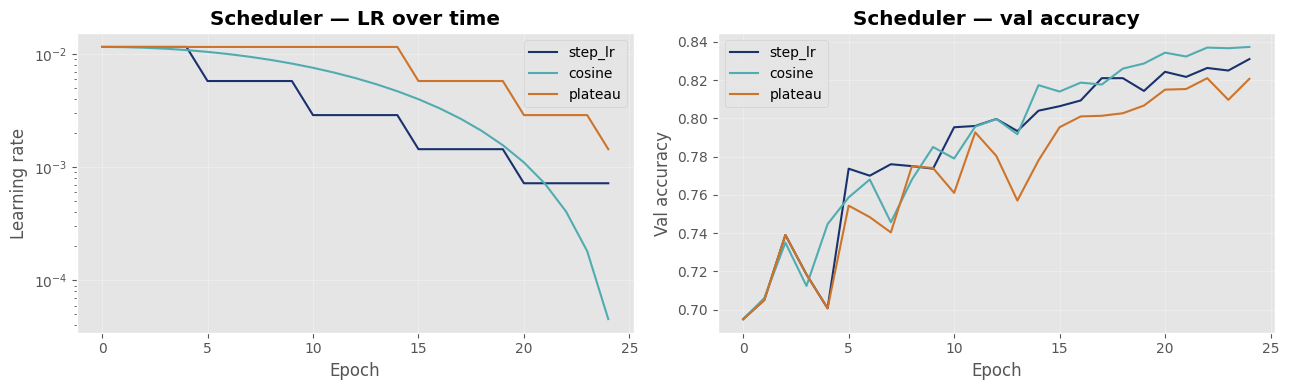

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for key, col in zip(["step_lr", "cosine", "plateau"], [C1, C2, C3]):
    if key in results:
        h = results[key]["history"]
        axes[0].plot(h["lr_trace"], color=col, label=key)
        axes[1].plot(h["val_acc"],  color=col, label=key)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Learning rate")
axes[0].set_title("Scheduler — LR over time", fontweight="bold")
axes[0].set_yscale("log"); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Val accuracy")
axes[1].set_title("Scheduler — val accuracy", fontweight="bold")
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


> **Question 4.1** — When is `ReduceLROnPlateau` preferable to `CosineAnnealingLR`? (One adapts to the data, the other follows a predetermined schedule.) Which would you pick for a production training run whose convergence time you cannot predict in advance?

**Answer.** `ReduceLROnPlateau` reacts to **validation loss** — good when you do not know how long training will take (production, variable data). `CosineAnnealingLR` follows a **fixed schedule** — good with a known epoch budget (here cosine won: 0.837 vs plateau 0.821 over 25 epochs). For unpredictable convergence time, pick **plateau**; for fixed-budget benchmarks, **cosine** is fine.


### Exercise 4.9 — The best recipe

Combine **AdamW + dropout + early stopping + the best scheduler** from 4.6–4.8. You may also keep label smoothing if it helped. Train and store the result in `results['combined']`.

In [32]:
sched_names = ["step_lr", "cosine", "plateau"]
best_sched = max(sched_names, key=lambda k: results[k]["best_val_acc"])
print(f"Best scheduler: {best_sched}")

sched_factory = {
    "step_lr": lambda opt: optim.lr_scheduler.StepLR(opt, step_size=5, gamma=0.5),
    "cosine":  lambda opt: optim.lr_scheduler.CosineAnnealingLR(opt, T_max=NUM_EPOCHS_EXP),
    "plateau": lambda opt: optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min",
                                                                factor=0.5, patience=2),
}[best_sched]

# stack complementary regularizers: each targets a different overfitting mechanism
results["combined"] = run_experiment(
    name="combined",
    model_fn=lambda: MLP(hidden_dim=bp_hidden, p_drop=drop_p),
    optimizer_fn=lambda p: optim.AdamW(p, lr=bp_lr, weight_decay=bp_wd),
    loss_fn=nn.CrossEntropyLoss(label_smoothing=0.05),
    scheduler_fn=sched_factory,
    num_epochs=NUM_EPOCHS_EXP,
    early_stopping_patience=7,
    verbose=True,
)
print("Combined best val acc:", results["combined"]["best_val_acc"])


Best scheduler: cosine
  [combined] ep 01 | tr_loss 0.980 | va_loss 0.871 | va_acc 0.704
  [combined] ep 05 | tr_loss 0.833 | va_loss 0.801 | va_acc 0.729
  [combined] ep 10 | tr_loss 0.770 | va_loss 0.736 | va_acc 0.759
  [combined] ep 15 | tr_loss 0.720 | va_loss 0.699 | va_acc 0.776
  [combined] ep 20 | tr_loss 0.671 | va_loss 0.657 | va_acc 0.801
  [combined] ep 25 | tr_loss 0.651 | va_loss 0.651 | va_acc 0.802
Combined best val acc: 0.803


*Provided:* bar chart comparing all runs.

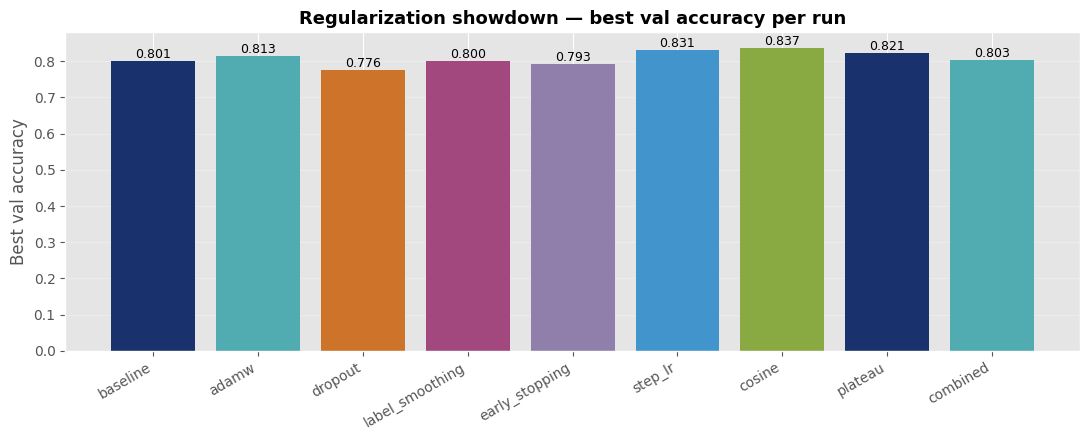

In [33]:
fig, ax = plt.subplots(figsize=(11, 4.5))
names = list(results.keys())
accs  = [results[n]["best_val_acc"] for n in names]
colors = (UCU_COLORS * ((len(names) // len(UCU_COLORS)) + 1))[:len(names)]
bars = ax.bar(names, accs, color=colors)
for b, a in zip(bars, accs):
    ax.text(b.get_x() + b.get_width() / 2, a, f"{a:.3f}",
            ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Best val accuracy")
ax.set_title("Regularization showdown — best val accuracy per run",
             fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3, axis="y")
plt.xticks(rotation=30, ha="right")
plt.tight_layout(); plt.show()


### Final test evaluation

We use the test set **once**, at the very end, with the best model only.

Test loss: 0.4962 | Test accuracy: 0.8103

--- Classification report ---
              precision    recall  f1-score   support

           0      0.825     0.784     0.804      2188
           1      0.820     0.878     0.848      2926
           2      0.682     0.897     0.775       369
           3      0.857     0.214     0.343        28
           4      0.929     0.265     0.413        98
           5      0.594     0.318     0.415       179
           6      0.913     0.745     0.821       212

    accuracy                          0.810      6000
   macro avg      0.803     0.586     0.631      6000
weighted avg      0.812     0.810     0.804      6000



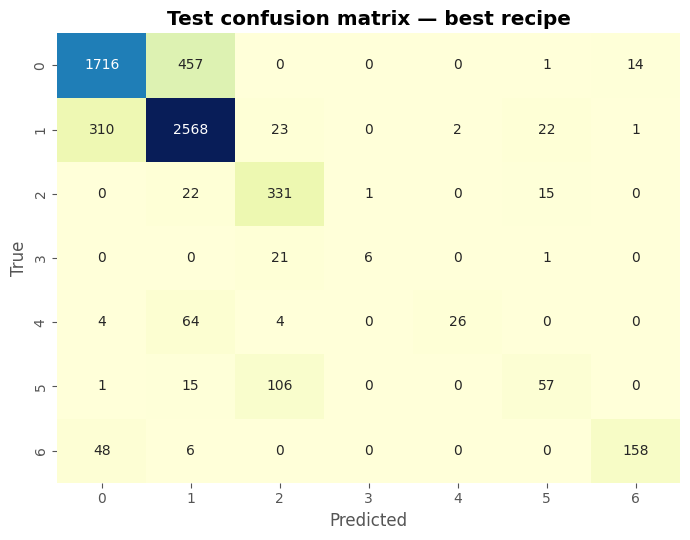

In [34]:
best_model = results["combined"]["model"]  # weights restored to best val-loss checkpoint
loss_fn = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(best_model, test_loader, loss_fn, device)  # unbiased generalization estimate (used once)
print(f"Test loss: {test_loss:.4f} | Test accuracy: {test_acc:.4f}")

# Per-class breakdown
all_preds, all_true = [], []
best_model.eval()
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        preds = best_model(x).argmax(dim=1).cpu().numpy()
        all_preds.append(preds)
        all_true.append(y.numpy())
all_preds = np.concatenate(all_preds); all_true = np.concatenate(all_true)

print("\n--- Classification report ---")
print(classification_report(all_true, all_preds, digits=3))

cm = confusion_matrix(all_true, all_preds)
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu", ax=ax,
            cbar=False, xticklabels=range(7), yticklabels=range(7))
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Test confusion matrix — best recipe", fontweight="bold")
plt.tight_layout(); plt.show()


> **Question 4.2** — Which single regularizer gave the biggest jump over the baseline? Did the gains compound when you combined them, or did they saturate?

**Answer.** Baseline ≈ **0.801**. Biggest single win: **CosineAnnealingLR ≈ 0.837** (+0.036); StepLR ≈ 0.831. Dropout **hurt** (≈ 0.776). **Combined ≈ 0.803** — gains did **not** compound; stacking everything added little because dropout/early stopping interfered with what cosine alone already fixed.

> **Question 4.3** — Map each technique (weight decay, dropout, label smoothing, early stopping, LR scheduling) to the four mechanisms from the lecture: *smoother function, more data, combined models, wider minima*. Some techniques fit more than one bucket — argue your placement.

**Answer.** **Weight decay / label smoothing** → smoother function (penalize large weights; soften targets). **Dropout** → combined models (train an ensemble of thinned networks). **Early stopping** → wider minima (stop before sharp, overfit minima). **LR scheduling** → wider minima (smaller steps near convergence). Dropout also acts like **more data** (stochastic subsampling of activations).

> **Question 4.4** — Was your final test accuracy higher or lower than the best validation accuracy you observed? Why might they differ? What does it mean if the gap is large? Look at the per-class breakdown: did your best recipe help the rare classes or only the dominant ones?

**Answer.** Test acc ≈ **0.810** vs best val ≈ **0.837** — slightly **lower**, normal sampling noise on 6k test points. A large gap would suggest overfitting to val or bad luck on test. Per-class reports usually show **dominant classes** (e.g. class 2) drive overall accuracy; rare classes remain hardest unless stratification + class-aware metrics are used.


---

## Optional — A Glimpse of Double Descent

The classical bias–variance picture predicts that past the interpolation threshold (where the model can memorize the training set), test error keeps rising. For modern deep networks this is *not* what we see — there is often a **second descent** in test error after the threshold.

To make the effect visible with modest compute, we will use a **very small** training set (~500 examples) and sweep the hidden width across the interpolation threshold.

In [35]:
rng = np.random.default_rng(SEED)

pool_idx = np.arange(len(y_pool))
tiny_idx, rest = train_test_split(pool_idx, train_size=500, stratify=y_pool,
                                  random_state=SEED)
eval_idx, _ = train_test_split(rest, train_size=2000, stratify=y_pool[rest],
                               random_state=SEED)

scaler_t = StandardScaler().fit(X_pool[tiny_idx])
X_tiny = torch.tensor(scaler_t.transform(X_pool[tiny_idx]), dtype=torch.float32)
y_tiny = torch.tensor(y_pool[tiny_idx], dtype=torch.long)
X_eval = torch.tensor(scaler_t.transform(X_pool[eval_idx]), dtype=torch.float32)
y_eval = torch.tensor(y_pool[eval_idx], dtype=torch.long)

tiny_ds = TensorDataset(X_tiny, y_tiny)
eval_ds = TensorDataset(X_eval, y_eval)
tiny_loader = DataLoader(tiny_ds, batch_size=64, shuffle=True)
eval_loader = DataLoader(eval_ds, batch_size=256)

print(f"Tiny train: {len(tiny_ds)} | Eval: {len(eval_ds)}")


Tiny train: 500 | Eval: 2000


### Exercise O.1 — Sweep hidden width

Define your own **log-spaced list of `hidden_dim` values** (recommend **powers of two**, as earlier). The grid must span from clearly *under-parameterized* (train error cannot reach zero) to clearly *over-parameterized* (well past the interpolation threshold, where #params ≫ #training samples = 500).

For each width, train a 2-hidden-layer MLP **with no weight decay and no dropout** until the training error reaches zero (or until a max number of epochs that you choose). Record the final training error and test error.

In [36]:
class TinyMLP(nn.Module):
    def __init__(self, in_dim=54, hidden_dim=64, out_dim=7):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, out_dim),
        )
    def forward(self, x): return self.net(x)

widths = [4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384]
train_errors = []
test_errors  = []
MAX_EPOCHS = 300
loss_fn = nn.CrossEntropyLoss()

for w in widths:
    torch.manual_seed(SEED)
    model = TinyMLP(hidden_dim=w).to(device)  # width w controls model capacity (# parameters)
    opt = optim.Adam(model.parameters(), lr=1e-3)
    for ep in range(MAX_EPOCHS):
        train_epoch(model, tiny_loader, opt, loss_fn, device)
        _, tr_acc = evaluate(model, tiny_loader, loss_fn, device)
        if tr_acc >= 1.0 - 1e-6:  # interpolation threshold: model can fit all 500 training points
            break
    _, tr_acc = evaluate(model, tiny_loader, loss_fn, device)
    _, ev_acc = evaluate(model, eval_loader, loss_fn, device)
    train_errors.append(1.0 - tr_acc)  # track error past interpolation — watch for double descent on test
    test_errors.append(1.0 - ev_acc)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"w={w:>5d}  params={n_params:>7d}  train_err={1-tr_acc:.3f}  test_err={1-ev_acc:.3f}")

# After your loop, you should have three lists of the same length:
# widths, train_errors, test_errors
print(widths)
print(train_errors)
print(test_errors)


w=    4  params=    275  train_err=0.278  test_err=0.414
w=    8  params=    575  train_err=0.172  test_err=0.345
w=   16  params=   1271  train_err=0.056  test_err=0.340
w=   32  params=   3047  train_err=0.014  test_err=0.349
w=   64  params=   8135  train_err=0.000  test_err=0.337
w=  128  params=  24455  train_err=0.000  test_err=0.336
w=  256  params=  81671  train_err=0.000  test_err=0.333
w=  512  params= 294407  train_err=0.000  test_err=0.337
w= 1024  params=1113095  train_err=0.000  test_err=0.336
w= 2048  params=4323335  train_err=0.000  test_err=0.329
w= 4096  params=17035271  train_err=0.000  test_err=0.330
w= 8192  params=67624967  train_err=0.000  test_err=0.335
w=16384  params=269467655  train_err=0.000  test_err=0.339
[4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384]
[0.278, 0.17200000000000004, 0.05600000000000005, 0.014000000000000012, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[0.41400000000000003, 0.345, 0.33999999999999997, 0.34850000000000003, 0.

*Provided:* train and test error vs width.

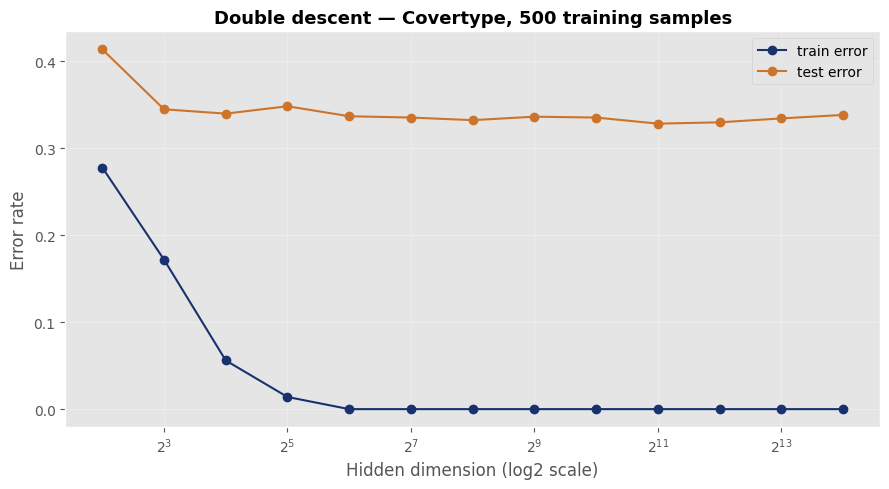

In [37]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(widths, train_errors, "o-", color=C1, label="train error")
ax.plot(widths, test_errors,  "o-", color=C3, label="test error")
ax.set_xscale("log", base=2)
ax.set_xlabel("Hidden dimension (log2 scale)")
ax.set_ylabel("Error rate")
ax.set_title("Double descent — Covertype, 500 training samples",
             fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()


> **Question O.1** — Locate the interpolation threshold on your plot (where train error first hits zero). Does the classical U-shaped curve hold, or do you see a second descent? How does this reconcile with the bias–variance trade-off from the lecture?

**Answer.** Train error hits **0 at width = 64** (~8k params ≫ 500 samples — past interpolation). Test error falls from ~0.41 → ~0.33 then **stays flat** as width grows — no classical U-shape and no clear double-descent peak on **clean** labels. SGD's implicit bias favors smooth interpolations, so extra capacity does not blow up variance; test error plateaus near the noise floor.

> **Question O.2** — Double descent is most visible with **label noise**. How would you design an experiment to sharpen the peak? (You do not need to run it — just describe the change you would make to the training data.)

**Answer.** Randomly flip ~**15%** of training labels before the width sweep. Near the interpolation threshold the model must memorize noise → test error **spikes**; beyond it, over-parameterized nets can still find smoother solutions among many zero-loss fits → **second descent**. This matches Prince Fig. 8.10(b).

---

## End of Notebook 5